# 02 — Dynamic Time Warping

**Dataset:** `aim_2023`

**Question:** Do time-warped windows recur at signal-derived candidate periods?

## Method

Compare period-separated windows against non-period controls using one-second Sakoe-Chiba bands resolved at native sample rate.

In [1]:
from pathlib import Path
import sys

ROOT = Path.cwd().resolve()
while ROOT != ROOT.parent and not (ROOT / "lap_estimation").exists():
    ROOT = ROOT.parent
if not (ROOT / "lap_estimation").exists():
    raise FileNotFoundError("Repository root not found")
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from lap_estimation.plotting_classical import render_dtw_diagnostics
from lap_estimation.artifacts import load_experiment_metrics
from lap_estimation.config import RANDOM_SEED
from lap_estimation.data import prepare_recording_manifest
from lap_estimation.datasets import resolve_dataset
from lap_estimation.runners import run_experiment

DATASET_KEY = "aim_2023"
dataset = resolve_dataset(DATASET_KEY, ROOT)
ARTIFACT_ROOT = dataset.artifact_root
np.random.seed(RANDOM_SEED)
sns.set_theme(style="ticks", palette="colorblind", context="notebook")
manifest = prepare_recording_manifest(dataset)
manifest[["recording_id", "duration_s", "motion_status", "control_candidate", "clock_provenance", "split"]]

,recording_id,duration_s,motion_status,control_candidate,clock_provenance,split
0,18385fe48224fbfa0cd6d17705d9305f857d70ef07b47b...,228.95,dynamic_candidate,False,inferred_uniform_from_metadata,train
1,27937681c8199780c6cbce603f217d5a4457c351e84fa3...,217.95,dynamic_candidate,False,inferred_uniform_from_metadata,train
2,4975a35d789765b9299480af66d6a5af5166fef074cef8...,210.95,dynamic_candidate,False,inferred_uniform_from_metadata,train
3,5790cd1534b1de5ac4693367fe5d8ca6951cd36a7abcd3...,25.95,low_dynamics_candidate,True,inferred_uniform_from_metadata,train
4,5c12d7b5eff374be805bae6c5e2906f6c02b6bc3ad6ba7...,89.95,dynamic_candidate,False,inferred_uniform_from_metadata,train
5,5c8af6b8a89a449144e0ddf74414040b433d630e1fd3d3...,33.95,low_dynamics_candidate,True,inferred_uniform_from_metadata,train
6,6732a35a8f6343dcf041f1a3ad40d6760331513a2556c4...,21.95,dynamic_candidate,False,inferred_uniform_from_metadata,train
7,7208a43e77536a72e401c00f01a793130fb6688d28fb80...,9.95,low_dynamics_candidate,True,inferred_uniform_from_metadata,train
8,73093667f33a7f710fc20059989a002071359119e1e9c0...,10.95,low_dynamics_candidate,True,inferred_uniform_from_metadata,train
9,8f799d59c9b5348ece1e5671692ea783d6d5e450ccebe3...,107.95,dynamic_candidate,False,inferred_uniform_from_metadata,train


In [2]:
EXPERIMENT_OPTIONS = {}
EXPERIMENT_OPTIONS

{}

,task,split,metric,value,sample_count,reference_source
0,period_pair_retrieval,train,median_matched_dtw,0.939389,62,signal_period_teacher
1,period_pair_retrieval,train,matched_better_than_control_rate,0.822581,62,within_recording_control
2,period_pair_retrieval,validation,median_matched_dtw,25.378825,10,signal_period_teacher
3,period_pair_retrieval,validation,matched_better_than_control_rate,0.300000,10,within_recording_control
4,period_pair_retrieval,test,median_matched_dtw,0.369471,20,signal_period_teacher
5,period_pair_retrieval,test,matched_better_than_control_rate,0.700000,20,within_recording_control
6,period_pair_retrieval,all,median_matched_dtw,0.644651,92,signal_period_teacher
7,period_pair_retrieval,all,matched_better_than_control_rate,0.739130,92,within_recording_control


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
recording_id,92,10,18385fe48224fbfa0cd6d17705d9305f857d70ef07b47b...,10,NaN,NaN,NaN,NaN,NaN,NaN,NaN
segment_id,92,10,pair_0,10,NaN,NaN,NaN,NaN,NaN,NaN,NaN
start_s,92.0,NaN,NaN,NaN,8.826087,5.833983,0.0,4.0,8.0,14.0,18.0
end_s,92.0,NaN,NaN,NaN,18.826087,5.833983,10.0,14.0,18.0,24.0,28.0
prediction_kind,92,1,dtw_period_match,92,NaN,NaN,NaN,NaN,NaN,NaN,NaN
score,92.0,NaN,NaN,NaN,5.885014,11.434354,-21.536501,-0.007876,0.820259,8.845248,30.33697
label_status,92,1,provisional_unverified,92,NaN,NaN,NaN,NaN,NaN,NaN,NaN
predicted_period_s,92.0,NaN,NaN,NaN,35.043478,14.422996,15.05,21.0,39.95,45.5,59.15
matched_distance,92.0,NaN,NaN,NaN,5.632285,8.721241,0.175405,0.407925,0.644651,3.470633,27.356686
control_distance,92.0,NaN,NaN,NaN,11.517299,11.765662,0.281646,0.642341,3.869699,24.408278,30.944089


,count,mean,median,std,min,max
recording_id,,,,,,
27937681c8199780c6cbce603f217d5a4457c351e84fa3cd7cfc62bfd270c550,10,16.420960,21.964125,14.428919,-0.023926,30.336970
4975a35d789765b9299480af66d6a5af5166fef074cef80facbac97409b84d07,10,15.756163,20.480237,12.394560,-0.144218,28.621528
8f799d59c9b5348ece1e5671692ea783d6d5e450ccebe31b6db9ad4f9510f8c5,10,6.083641,6.738922,3.028239,0.186931,11.559929
18385fe48224fbfa0cd6d17705d9305f857d70ef07b47b55502d04ff71359269,10,9.932838,1.714187,12.287711,-0.322600,27.467127
9116cbf4be063f5be851f65778ddfb91d60bdd5aa52e7211426769a6b2ce6f86,10,3.913711,0.786747,10.539702,-10.046678,18.822907
5c12d7b5eff374be805bae6c5e2906f6c02b6bc3ad6ba70d3674bafd4f16fc15,10,0.321720,0.487705,1.126027,-1.535826,1.991071
5c8af6b8a89a449144e0ddf74414040b433d630e1fd3d3ddc138ec3c4284d97b,2,0.198161,0.198161,0.077467,0.143383,0.252938
dc8bf44eb4cc0becf1c5ebe252a515c98193744c2031498501de80e036899758,10,0.032729,0.035632,0.027737,-0.006106,0.074768
bace0e92b25324e8afbd0e5f6698b01a921780a2385e02419965fa97e3e796c4,10,7.171487,-0.017128,10.647102,-0.259355,23.778937


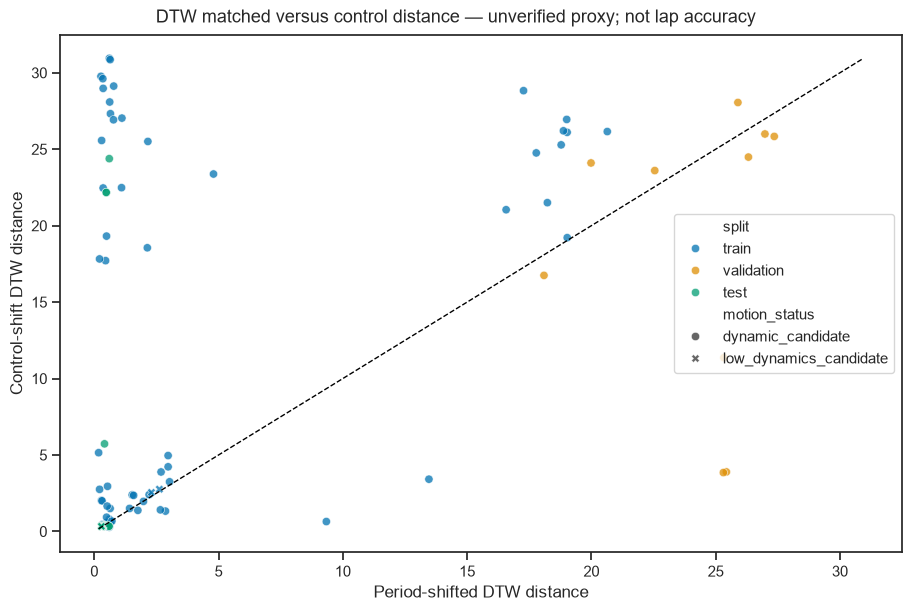

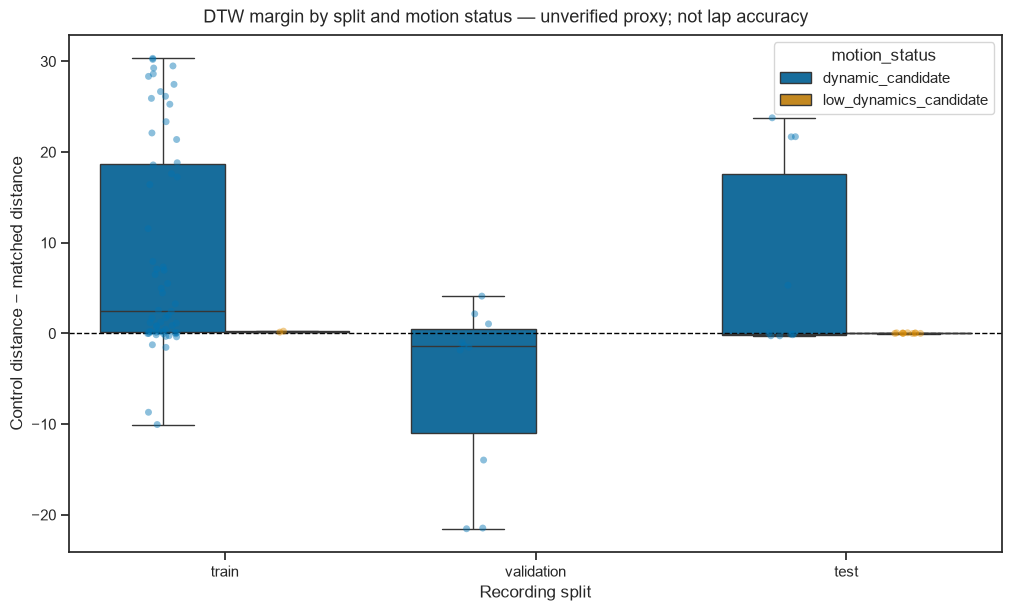

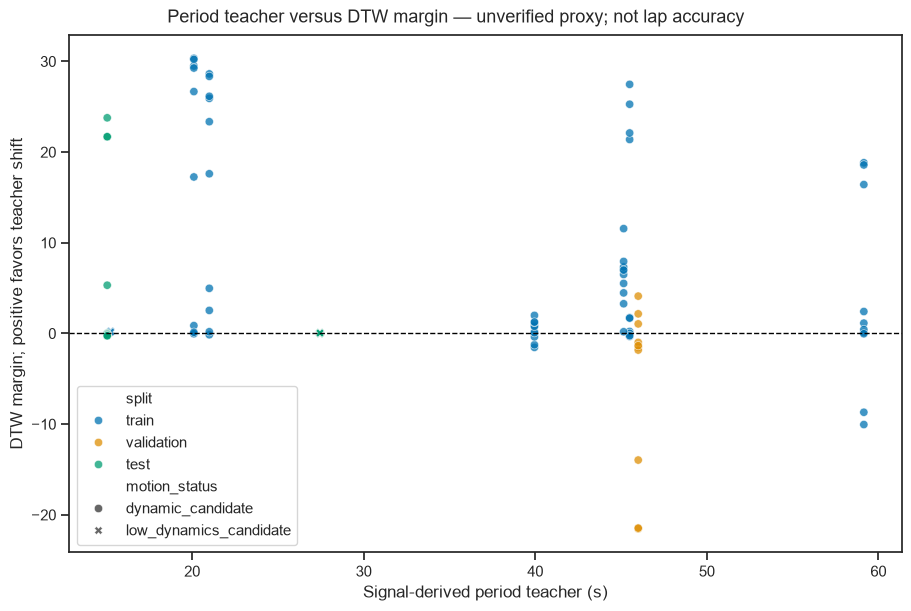

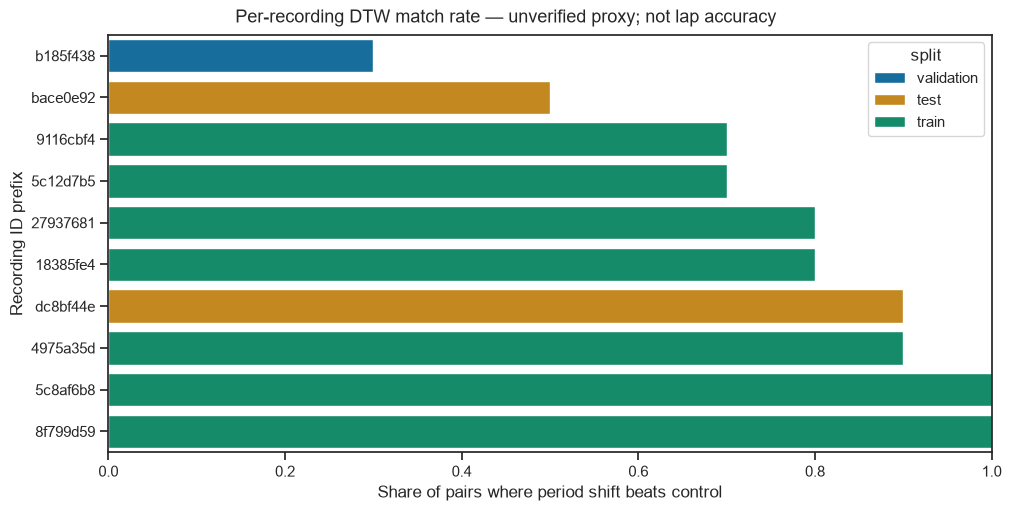

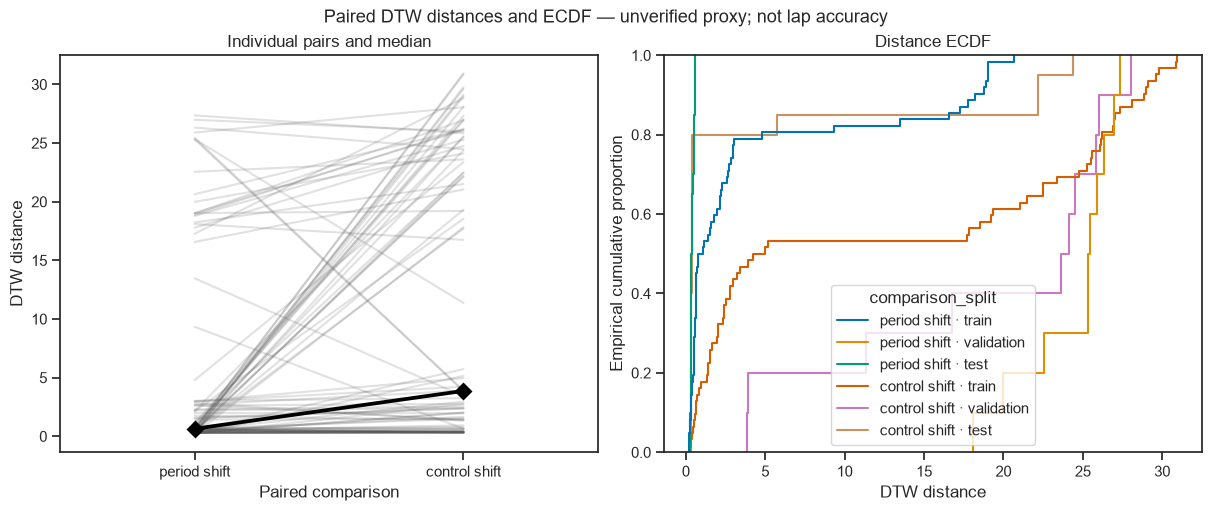

In [3]:
METHOD = "02_dtw"
result = run_experiment(METHOD, ROOT, dataset_key=DATASET_KEY, **EXPERIMENT_OPTIONS)
run_manifest = json.loads((result.output_dir / "manifest.json").read_text(encoding="utf-8"))
display(result.metrics)
display(result.predictions.describe(include="all").T)
display(result.predictions.groupby("recording_id")["score"].agg(["count", "mean", "median", "std", "min", "max"]).sort_values("median", ascending=False))
diagnostic_figures = render_dtw_diagnostics(result.predictions, run_manifest, result.output_dir)
for figure in diagnostic_figures.values():
    display(figure)
    plt.close(figure)

In [4]:
pd.Series(
    {
        "status": run_manifest["status"],
        "runtime_s": run_manifest["runtime_s"],
        "clock_provenance": run_manifest["data_provenance"]["clock_provenance"],
        "sample_rate_hz": run_manifest["data_provenance"]["native_sample_rate_hz"],
        "channels": run_manifest["data_provenance"]["selected_channels"],
        "label_provenance": run_manifest["label_provenance"],
    },
    name="value",
).to_frame()

,value
status,complete
runtime_s,6.412
clock_provenance,inferred_uniform_from_metadata
sample_rate_hz,20.0
channels,"[InlineAcc, LateralAcc, RollRate, PitchRate, Y..."
label_provenance,signal_period_teacher_unverified


## Reading

Positive held-out control margin supports teacher-period matching only. It does not validate laps.

No lap precision, recall, count error, or duration error can be reported without independently reviewed boundaries.